In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.preprocessing
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
df=pd.read_excel('CS_11TH_Topics_complete.xlsx')

In [3]:
df.head()

,Year,Topic_id,Topic,Appeared,Chapter_Name
0,2016,7.2,Basic Database Terminologies,1,Database Fundamentals
1,2016,1.1.1,Computing Devices,1,Overview of Computer System
2,2016,1.1.2,Computer and its Basic Operations,1,Overview of Computer System
3,2016,1.1.3,Classification of Computers,1,Overview of Computer System
4,2016,1.1.4,Hardware and Software,1,Overview of Computer System


In [4]:
df.isnull().sum()

Year            0
Topic_id        0
Topic           0
Appeared        0
Chapter_Name    0
dtype: int64

In [5]:
df['Chapter_Name'].unique()

array(['Database Fundamentals', 'Overview of Computer System',
       'Computer Memory', 'Central Processing Unit', 'Inside System Unit',
       'Network Communication and Protocols', 'Wireless Communications',
       'Database Development'], dtype=object)

In [6]:
chapter_weight_map = {
    'Database Fundamentals':                 0.179,
    'Overview of Computer System':           0.147,
    'Computer Memory':                       0.105,
    'Central Processing Unit':               0.147,
    'Inside System Unit':                    0.105,
    'Network Communication and Protocols':   0.158,
    'Wireless Communications':               0.095,
    'Database Development':                  0.063,
}

In [7]:
df['chapter_weight'] = df['Chapter_Name'].map(chapter_weight_map)

In [8]:
df = df.sort_values(['Topic', 'Year']).reset_index(drop=True)

In [10]:
available_years = sorted(df['Year'].unique())

gaps = []
last_idx_appeared = {}
for _, row in df.iterrows():
    exercise = row['Topic']
    year = row['Year']
    appeared = row['Appeared']
    
    current_idx = available_years.index(year)
    
    if exercise not in last_idx_appeared:
        gaps.append(-1)
    else:
        gaps.append(current_idx - last_idx_appeared[exercise])
    
    if appeared == 1:
        last_idx_appeared[exercise] = current_idx

df['Gaps'] = gaps

In [11]:
years_in_data = df['Year'].unique()

frequency = []

for _, row in df.iterrows():
    topic = row['Topic']
    year = row['Year']
    
    # Pichle 5 available years nikalo (current year se pehle)
    prev_years = [y for y in years_in_data if y < year]
    last_5_years = prev_years[-5:]
    
    # Us topic ki un years mein appeared values nikalo
    topic_data = df[df['Topic'] == topic]
    count = topic_data[topic_data['Year'].isin(last_5_years)]['Appeared'].sum()
    
    frequency.append(int(count))

df['Frequency_Last_5'] = frequency

In [12]:
df['Appeared_last_year'] = df.groupby('Topic')['Appeared'].shift(1).fillna(0).astype(int)

In [13]:
df['rolling_3'] = (df.groupby('Topic')['Appeared']
                   .transform(lambda x: x.shift(1).rolling(3).sum())
                   .fillna(0))

In [14]:
df.isnull().sum()

Year                  0
Topic_id              0
Topic                 0
Appeared              0
Chapter_Name          0
chapter_weight        0
Gaps                  0
Frequency_Last_5      0
Appeared_last_year    0
rolling_3             0
dtype: int64

In [15]:
df_model=df.copy()

## Train Test Split
Here we'll experiment to check how well our model understands pattern that's why we train data on ```2024,2023,2022,2019,2018,2017,2016``` and test on the paper of ```2025```

In [16]:
train = df_model[df_model['Year'] < 2025]
test  = df_model[df_model['Year'] == 2025]

features = ['Gaps', 'Frequency_Last_5','Appeared_last_year','rolling_3','chapter_weight']
targets = 'Appeared'

X_train = train[features]
y_train = train[targets]

X_test = test[features]
y_test = test[targets]

## Baseline Model
  ### ***. LogisticRegression***

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [18]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

### Accuracy , Precision , Recall

In [19]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
y_prob_lr = pipe.predict_proba(X_test)[:, 1]
accuracy_lr = accuracy_score(y_test, y_pred)
precision_lr = precision_score(y_test, y_pred)
recall_lr = recall_score(y_test, y_pred)
print(f"Accuracy:  {accuracy_lr * 100:.2f}%")
print(f'Precision:{precision_lr*100:.2f}%')
print(f'Recall:{recall_lr*100:.2f}%')

Accuracy:  73.12%
Precision:57.41%
Recall:93.94%


## Dummy Classifier

In [20]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(f"Dummy Accuracy: {accuracy_score(y_test, dummy.predict(X_test)):.4f}")

Dummy Accuracy: 0.6452


### Accuarcy , Classification Report On Different Threshold

In [21]:
from sklearn.metrics import classification_report

y_prob_lr = pipe.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.25]:
    y_pred_thresh = (y_prob_lr >= threshold).astype(int)
    print(f'Accuracy:{accuracy_score(y_test,y_pred_thresh)*100:.2f}%')
    print(f"\nThreshold={threshold}")
    print(classification_report(y_test, y_pred_thresh))

Accuracy:73.12%

Threshold=0.5
              precision    recall  f1-score   support

           0       0.95      0.62      0.75        60
           1       0.57      0.94      0.71        33

    accuracy                           0.73        93
   macro avg       0.76      0.78      0.73        93
weighted avg       0.82      0.73      0.74        93

Accuracy:65.59%

Threshold=0.4
              precision    recall  f1-score   support

           0       0.97      0.48      0.64        60
           1       0.51      0.97      0.67        33

    accuracy                           0.66        93
   macro avg       0.74      0.73      0.66        93
weighted avg       0.80      0.66      0.65        93

Accuracy:52.69%

Threshold=0.3
              precision    recall  f1-score   support

           0       1.00      0.27      0.42        60
           1       0.43      1.00      0.60        33

    accuracy                           0.53        93
   macro avg       0.71      0.63  

### Prediction For 2026

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1 - Full data pe train karo
features = ['Gaps', 'Frequency_Last_5', 'Appeared_last_year', 'rolling_3', 'chapter_weight']
targets = 'Appeared'

X_full = df_model[features].copy()
y_full = df_model[targets]

pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe_full.fit(X_full, y_full)

# Step 2 - 2026 ka base
df_2026 = df[df['Year'] == 2025][['Topic_id', 'Topic', 'Chapter_Name', 'Appeared', 'Gaps',
              'Frequency_Last_5', 'Appeared_last_year',
              'rolling_3', 'chapter_weight']].copy()
df_2026['Year'] = 2026

# Step 3 - Features update
df_2026['Appeared_last_year'] = df_2026['Appeared']
df_2026['Gaps'] = df_2026.apply(
    lambda row: 1 if row['Appeared'] == 1 else row['Gaps'] + 1, axis=1)
df_2026['Frequency_Last_5'] = df_2026.apply(
    lambda row: min(5, row['Frequency_Last_5'] + row['Appeared']), axis=1)
df_2026['rolling_3'] = df_2026.apply(
    lambda row: min(3, row['rolling_3'] + row['Appeared']), axis=1)

# Step 4 - Predict
X_2026 = df_2026[features].copy()
prob_2026 = pipe_full.predict_proba(X_2026)[:, 1]
df_2026['Probability'] = prob_2026

# Step 5 - Filter + Category
result_2026 = df_2026[['Topic_id', 'Topic', 'Chapter_Name', 'Probability']]\
              .sort_values('Probability', ascending=False)\
              .reset_index(drop=True)

final_predictions = result_2026[result_2026['Probability'] >= 0.5].head(25).copy()

final_predictions['Category'] = final_predictions['Probability'].apply(
    lambda x: 'A - Must Prepare' if x >= 0.7 else 'B - Should Prepare'
)

# Step 6 - Years appeared nikalo
appeared_years_list = []
for _, row in final_predictions.iterrows():
    topic = row['Topic']
    years = df[
        (df['Topic'] == topic) &
        (df['Appeared'] == 1)
    ]['Year'].tolist()
    appeared_years_list.append(', '.join(map(str, sorted(years))))

final_predictions['Years_Appeared'] = appeared_years_list
final_predictions['Total_Appearances'] = final_predictions['Years_Appeared'].apply(
    lambda x: len(x.split(', ')) if x else 0
)

# Step 7 - Save
final_predictions.to_excel('Computer_1stYear_Predictions_2026.xlsx', index=False)
print(final_predictions)

   Topic_id                                              Topic  \
0     7.1.4                  Database Management System (DBMS)   
1     5.3.4                                      IP Addressing   
2     5.1.2                             Modes of Communication   
3     5.1.7                                 Network Topologies   
4     5.1.3                                Communication Media   
5     1.1.3                        Classification of Computers   
6     1.2.1                                  Types of Software   
7     1.2.2                           Types of System Software   
8     3.2.3                                  Instruction Cycle   
9     3.1.1                            Basic Components of CPU   
10    1.1.1                                  Computing Devices   
11    7.4.1            Elements of Entity Relationship Diagram   
12    7.1.5  Advantages of DBMS over the File Management Sy...   
13    2.2.2                   Volatile and Non-Volatile Memory   
14    4.2.

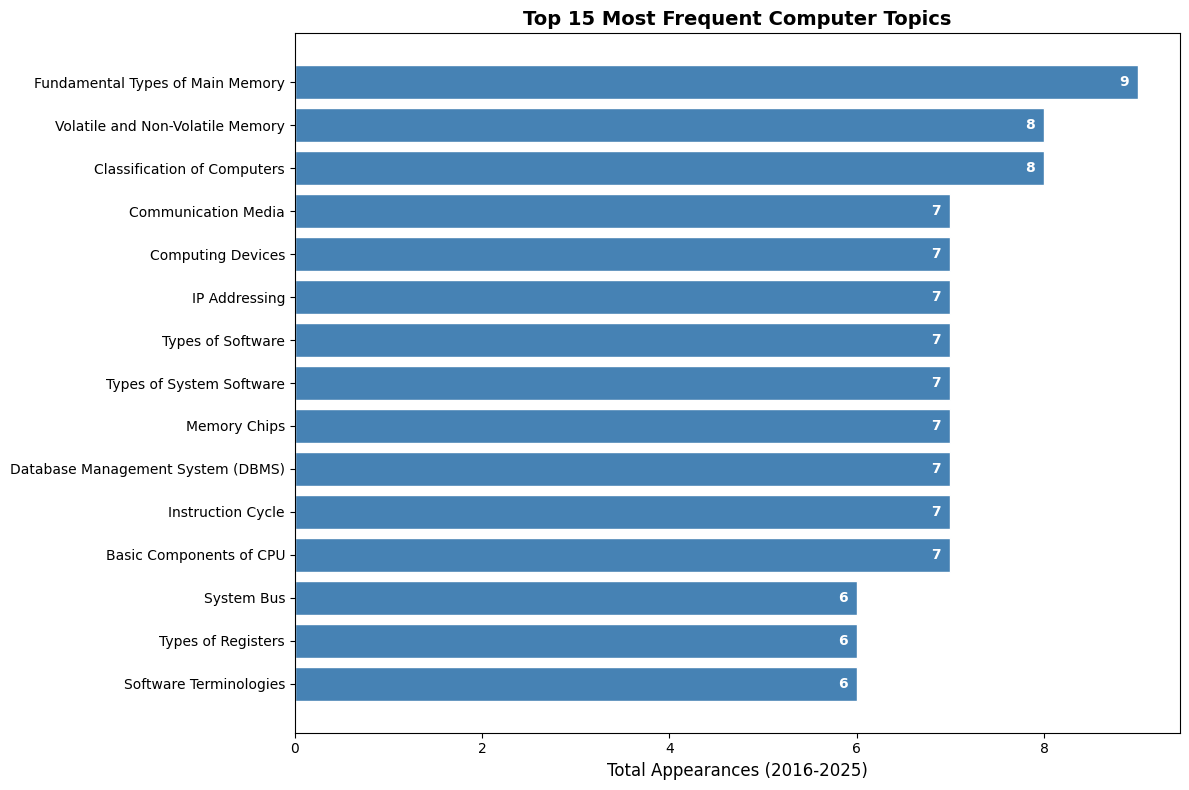

In [24]:
import matplotlib.pyplot as plt

topic_freq = df.groupby('Topic')['Appeared'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(topic_freq.index, topic_freq.values, color='steelblue', edgecolor='white')
plt.xlabel('Total Appearances (2016-2025)', fontsize=12)
plt.title('Top 15 Most Frequent Computer Topics', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Values bar ke andar dikhao
for bar, val in zip(bars, topic_freq.values):
    plt.text(val - 0.1, bar.get_y() + bar.get_height()/2, 
             str(int(val)), va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph1_frequency.png', dpi=150)
plt.show()

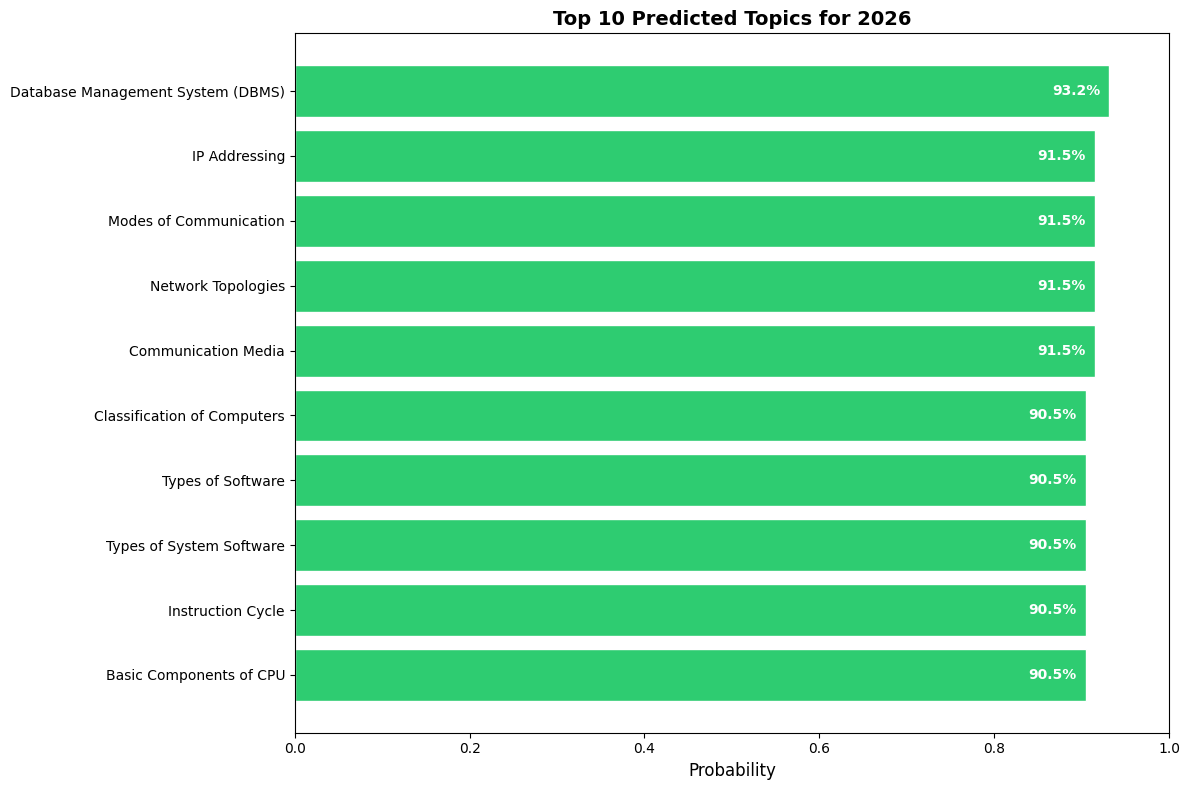

In [25]:
top10 = result_2026.head(10)

plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if p >= 0.85 else '#f39c12' if p >= 0.80 else '#e74c3c' 
          for p in top10['Probability']]
bars = plt.barh(top10['Topic'], top10['Probability'], color=colors, edgecolor='white')
plt.xlabel('Probability', fontsize=12)
plt.title('Top 10 Predicted Topics for 2026', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.gca().invert_yaxis()

for bar, val in zip(bars, top10['Probability']):
    plt.text(val - 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph2_predictions.png', dpi=150)
plt.show()